In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# STEP 0 — Load Dataset

df = pd.read_csv("nifty50.csv")

# If your dataset has Date column
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Keep only required columns
df.columns = df.columns.str.strip()
df = df[['Open', 'High', 'Low', 'Close']]

print(df.head())
print("Shape:", df.shape)

             Open   High    Low  Close
Date                                  
2009-03-02  43.19  43.38  41.44  43.17
2009-03-03  43.17  43.90  41.20  43.89
2009-03-04  43.89  43.89  42.16  42.52
2009-03-05  42.52  42.71  40.41  41.49
2009-03-06  41.49  41.49  37.57  38.16
Shape: (3061, 4)


In [3]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [4]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

In [5]:
# Separate features and target
X_enet = scaled_df.drop(columns=["Close"]).values
y_enet = scaled_df["Close"].values

elastic = ElasticNet(alpha=0.0001, l1_ratio=0.5)
elastic.fit(X_enet, y_enet)

selected_indices = np.where(elastic.coef_ != 0)[0]

selected_columns = scaled_df.drop(columns=["Close"]).columns[selected_indices]
print("Selected Features:", selected_columns)

# Keep selected features + target
scaled_selected = scaled_df[list(selected_columns) + ["Close"]]

Selected Features: Index(['Open', 'High', 'Low'], dtype='object')


In [6]:
def create_sequences(data, target_column, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, target_column])
    return np.array(X), np.array(y)

target_col_index = scaled_selected.columns.get_loc("Close")

X, y = create_sequences(scaled_selected.values, target_col_index)

In [7]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [8]:
n_features = X_train.shape[2]

model = Sequential()

model.add(Bidirectional(
    LSTM(64, return_sequences=True),
    input_shape=(60, n_features)
))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

/Users/krish/stock_ml/venv/lib/python3.11/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        35,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,273 (524.50 KB)

 Trainable params: 134,273 (524.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0030 - val_loss: 2.5512e-04
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 8.8707e-04 - val_loss: 1.9940e-04
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 7.1454e-04 - val_loss: 1.8187e-04
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 6.7849e-04 - val_loss: 1.6515e-04
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 5.9468e-04 - val_loss: 1.4859e-04
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 5.8419e-04 - val_loss: 1.4596e-04
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 5.5895e-04 - val_loss: 1.8224e-04
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 5.3258e-04 - val_loss: 1.3351e-04
Epoch 9/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 5.4576e-04 - val_loss: 2.4917e-04
Epoch 10/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 4.9438e-04 - val_loss: 1.2701e-04
Epoch 11/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 5.1562e-04 - 

In [10]:
predictions = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [11]:
temp = np.zeros((len(predictions), scaled_selected.shape[1]))
temp[:, target_col_index] = predictions.flatten()

predictions_inverse = scaler.inverse_transform(temp)[:, target_col_index]

temp2 = np.zeros((len(y_test), scaled_selected.shape[1]))
temp2[:, target_col_index] = y_test

y_test_inverse = scaler.inverse_transform(temp2)[:, target_col_index]

In [12]:
rmse = np.sqrt(mean_squared_error(y_test_inverse, predictions_inverse))
mae = mean_absolute_error(y_test_inverse, predictions_inverse)
r2 = r2_score(y_test_inverse, predictions_inverse)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 1.971314024583314
MAE: 1.0384700893728485
R2: 0.9611361331484202


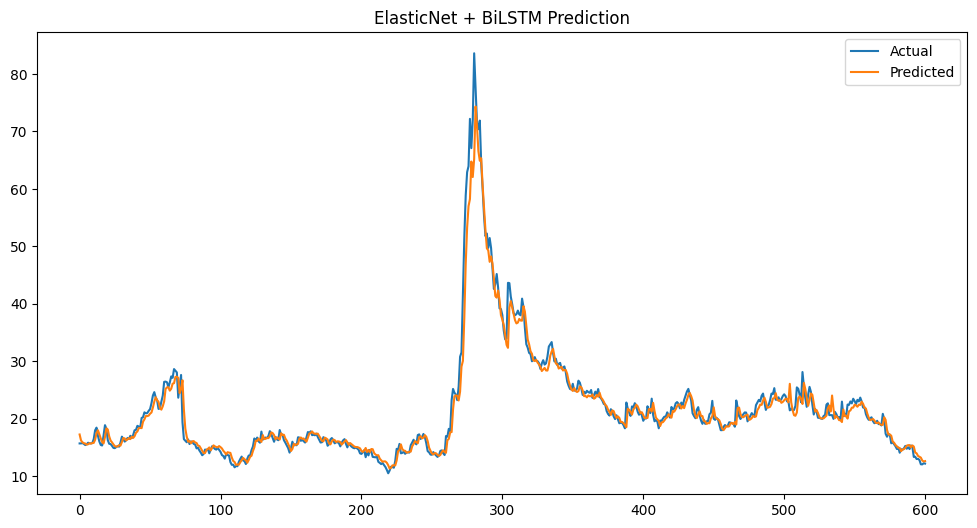

In [13]:
plt.figure(figsize=(12,6))
plt.plot(y_test_inverse, label="Actual")
plt.plot(predictions_inverse, label="Predicted")
plt.legend()
plt.title("ElasticNet + BiLSTM Prediction")
plt.show()